# Params

In [1]:
DATASET_DIR = './data'

TRAIN_MODEL = True
MODEL_SAVE_PATH = "./ner_model"

LR = 2e-5
BATCH_SIZE = 16
NUM_EPOCHS = 4
WEIGHT_DECAY = 0.01

# Setup

In [2]:
!pip install seqeval

In [3]:
import numpy as np
import pandas as pd
import kagglehub
import os
from seqeval.metrics import precision_score, recall_score, f1_score, classification_report
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForTokenClassification, DataCollatorForTokenClassification, Trainer, TrainingArguments
import torch

import warnings
warnings.filterwarnings(
    "ignore",
    message="Was asked to gather along dimension 0"
)
warnings.filterwarnings(
    "ignore",
    message="There were missing keys in the checkpoint model loaded"
)

print(torch.__version__)

/home/joachim/Desktop/University-NER/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2.11.0+cu130


In [4]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0)) 

True
NVIDIA GeForce RTX 5070 Ti


# Dataset handling
Loading, parsing, mapping, tokenizing

In [5]:
if not os.path.exists(DATASET_DIR):
    os.makedirs(DATASET_DIR)
    
path = kagglehub.dataset_download("alaakhaled/conll003-englishversion", output_dir=DATASET_DIR)
print(path)
print(os.listdir(path))

./data
['valid.txt', 'test.txt', 'metadata', 'train.txt', '.complete']


In [6]:
def load_conll_ner(file_path):
    sentences = []
    tokens, labels = [], []
    
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            
            if not line:
                if tokens:
                    sentences.append({"tokens": tokens, "ner_tags": labels})
                    tokens, labels = [], []
                continue
            
            if line.startswith("-DOCSTART-"):
                continue
            
            
            word, pos, chunk, ner = line.split()
            tokens.append(word)
            labels.append(ner)
    if tokens:
        sentences.append({"tokens": tokens, "ner_tags": labels})

    return sentences


train_data = load_conll_ner(f"{path}/train.txt")
val_data = load_conll_ner(f"{path}/valid.txt")
test_data  = load_conll_ner(f"{path}/test.txt")

train_dataset = Dataset.from_list(train_data)
val_dataset   = Dataset.from_list(val_data)
test_dataset  = Dataset.from_list(test_data)

print(f"Number of training sentences: {len(train_dataset)}")
print(f"Number of validation sentences: {len(val_dataset)}")
print(f"Number of test sentences: {len(test_dataset)}")

print("Example sentence:")
print(train_dataset[0])

Number of training sentences: 14041
Number of validation sentences: 3250
Number of test sentences: 3453
Example sentence:
{'tokens': ['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.'], 'ner_tags': ['B-ORG', 'O', 'B-MISC', 'O', 'O', 'O', 'B-MISC', 'O', 'O']}


In [ ]:
label_list = sorted(set(label for ex in train_dataset for label in ex["ner_tags"]))
label2id = {label: idx for idx, label in enumerate(label_list)}
id2label = {idx: label for label, idx in label2id.items()}
print("Label to ID mapping:")
print(label2id)
print("ID to Label mapping:")
print(id2label)


Label to ID mapping:
{'B-LOC': 0, 'B-MISC': 1, 'B-ORG': 2, 'B-PER': 3, 'I-LOC': 4, 'I-MISC': 5, 'I-ORG': 6, 'I-PER': 7, 'O': 8}
ID to Label mapping:
{0: 'B-LOC', 1: 'B-MISC', 2: 'B-ORG', 3: 'B-PER', 4: 'I-LOC', 5: 'I-MISC', 6: 'I-ORG', 7: 'I-PER', 8: 'O'}


In [ ]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")

def tokenize_dataset(dataset):
    def tokenize_and_align_labels(example):
        tokenized = tokenizer(
            example["tokens"],
            truncation=True,
            is_split_into_words=True
        )

        word_ids = tokenized.word_ids()
        labels = []
        previous_word = None
    
        for word_id in word_ids:
            if word_id is None:
                labels.append(-100)
            elif word_id != previous_word:
                labels.append(label2id[example["ner_tags"][word_id]])
            else:
                labels.append(-100)
            previous_word = word_id
    
        tokenized["labels"] = labels
        return tokenized
        
    dataset = dataset.map(tokenize_and_align_labels, batched=False)
    dataset = dataset.remove_columns(["tokens", "ner_tags"])
    return dataset

train_dataset = tokenize_dataset(train_dataset)
val_dataset = tokenize_dataset(val_dataset)
test_dataset = tokenize_dataset(test_dataset)

print("Tokenized example:")
print(train_dataset[0])

Map: 100%|██████████| 3453/3453 [00:00<00:00, 12968.94 examples/s]

Tokenized example:
{'input_ids': [101, 7270, 22961, 1528, 1840, 1106, 21423, 1418, 2495, 12913, 119, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'labels': [-100, 2, 8, 1, 8, 8, 8, 1, 8, -100, 8, -100]}


In [9]:
data_collator = DataCollatorForTokenClassification(tokenizer)

batch = data_collator([
    train_dataset[0],
    train_dataset[1]
])
print(batch)

{'input_ids': tensor([[  101,  7270, 22961,  1528,  1840,  1106, 21423,  1418,  2495, 12913,
           119,   102],
        [  101,  1943, 14428,   102,     0,     0,     0,     0,     0,     0,
             0,     0]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]]), 'labels': tensor([[-100,    2,    8,    1,    8,    8,    8,    1,    8, -100,    8, -100],
        [-100,    3,    7, -100, -100, -100, -100, -100, -100, -100, -100, -100]])}


# BERT
creating, training

In [10]:
model = AutoModelForTokenClassification.from_pretrained(
    "bert-base-cased",
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id
)

training_args = TrainingArguments(
    output_dir=MODEL_SAVE_PATH,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    learning_rate=LR,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=NUM_EPOCHS,
    weight_decay=WEIGHT_DECAY,
)

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 13823.37it/s]
[transformers] BertForTokenClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not

In [1]:
def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    true_predictions = []
    true_labels = []

    for pred, lab in zip(predictions, labels):
        cur_preds = []
        cur_labels = []

        for p_i, l_i in zip(pred, lab):
            if l_i != -100:
                cur_preds.append(id2label[p_i])
                cur_labels.append(id2label[l_i])

        true_predictions.append(cur_preds)
        true_labels.append(cur_labels)

    return {
        "precision": precision_score(true_labels, true_predictions),
        "recall": recall_score(true_labels, true_predictions),
        "f1": f1_score(true_labels, true_predictions),
    }

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

if TRAIN_MODEL:
    trainer.train()
    trainer.save_model(MODEL_SAVE_PATH + "/final_model")
    tokenizer.save_pretrained(MODEL_SAVE_PATH + "/final_model")
else:
    model = AutoModelForTokenClassification.from_pretrained(MODEL_SAVE_PATH + "/final_model")
    tokenizer = AutoTokenizer.from_pretrained(MODEL_SAVE_PATH + "/final_model")

    trainer = Trainer(
        model=model,
        args=training_args,
        eval_dataset=val_dataset,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics
    )

NameError: name 'Trainer' is not defined

# EVALUATION

In [12]:
predictions = trainer.predict(test_dataset)

preds = np.argmax(predictions.predictions, axis=2)
labels = predictions.label_ids

true_preds = []
true_labels = []

for pred, lab in zip(preds, labels):
    cur_preds = []
    cur_labels = []

    for p_i, l_i in zip(pred, lab):
        if l_i != -100:
            cur_preds.append(id2label[p_i])
            cur_labels.append(id2label[l_i])

    true_preds.append(cur_preds)
    true_labels.append(cur_labels)
    
print(classification_report(true_labels, true_preds))

              precision    recall  f1-score   support

         LOC       0.93      0.94      0.93      1668
        MISC       0.78      0.81      0.80       702
         ORG       0.88      0.91      0.89      1661
         PER       0.97      0.95      0.96      1617

   micro avg       0.90      0.92      0.91      5648
   macro avg       0.89      0.90      0.90      5648
weighted avg       0.91      0.92      0.91      5648



# Pytanie badawcze 2 (Fine-tuning): Wpływ pominięcia klasy na jakość predykcji

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

Q2_BERT_OMIT_CLASSES = [None, "PER", "ORG", "LOC", "MISC"]
Q2_BERT_MODEL_DIR    = "./q2_bert_models"
Q2_BERT_TRAIN        = True
Q2_CLASS_NAMES       = ["LOC", "MISC", "ORG", "PER"]

os.makedirs(Q2_BERT_MODEL_DIR, exist_ok=True)


def mask_ner_class(raw_data: list, omit_class) -> list:
    if omit_class is None:
        return raw_data
    drop = {f"B-{omit_class}", f"I-{omit_class}"}
    return [
        {"tokens": ex["tokens"],
         "ner_tags": ["O" if t in drop else t for t in ex["ner_tags"]]}
        for ex in raw_data
    ]


def build_trainer_q2(tok_train, tok_val, save_dir: str):
    m = AutoModelForTokenClassification.from_pretrained(
        "bert-base-cased",
        num_labels=len(label_list),
        id2label=id2label,
        label2id=label2id,
    )
    args = TrainingArguments(
        output_dir=save_dir,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        learning_rate=LR,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        num_train_epochs=NUM_EPOCHS,
        weight_decay=WEIGHT_DECAY,
        report_to="none",
    )
    return Trainer(
        model=m,
        args=args,
        train_dataset=tok_train,
        eval_dataset=tok_val,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )


def predict_q2_bert(trainer, test_ds):
    out = trainer.predict(test_ds)
    preds_raw = np.argmax(out.predictions, axis=2)
    true_preds, true_labels = [], []
    for p_row, l_row in zip(preds_raw, out.label_ids):
        ps, ls = [], []
        for p_i, l_i in zip(p_row, l_row):
            if l_i != -100:
                ps.append(id2label[p_i])
                ls.append(id2label[l_i])
        true_preds.append(ps)
        true_labels.append(ls)
    return true_preds, true_labels


In [16]:
q2_bert_results = {}

for omit_class in Q2_BERT_OMIT_CLASSES:
    cfg            = f"no_{omit_class}" if omit_class else "baseline"
    save_dir       = os.path.join(Q2_BERT_MODEL_DIR, cfg)
    final_dir      = os.path.join(save_dir, "final_model")

    print(f"\n{'='*55}\nConfig: {cfg}")

    if Q2_BERT_TRAIN and not os.path.exists(final_dir):
        tok_train = tokenize_dataset(Dataset.from_list(mask_ner_class(train_data, omit_class)))
        tok_val   = tokenize_dataset(Dataset.from_list(mask_ner_class(val_data,   omit_class)))

        t = build_trainer_q2(tok_train, tok_val, save_dir)
        t.train()
        t.save_model(final_dir)
        tokenizer.save_pretrained(final_dir)
    else:
        m = AutoModelForTokenClassification.from_pretrained(final_dir)
        _args = TrainingArguments(
            output_dir=save_dir,
            per_device_eval_batch_size=BATCH_SIZE,
            report_to="none",
        )
        t = Trainer(
            model=m,
            args=_args,
            processing_class=tokenizer,
            data_collator=data_collator,
            compute_metrics=compute_metrics,
        )

    true_preds, true_labels = predict_q2_bert(t, test_dataset)
    q2_bert_results[cfg] = (true_preds, true_labels)
    print(classification_report(true_labels, true_preds))

print("\nQ2 BERT — wszystkie konfiguracje gotowe.")



Config: baseline


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 13915.09it/s]
[transformers] BertForTokenClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not

Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,0.170028,0.042132,0.922898,0.936722,0.929759
2,0.028544,0.039062,0.947183,0.950690,0.948933
3,0.015391,0.038074,0.948276,0.953383,0.950822
4,0.009184,0.039012,0.947711,0.954729,0.951207


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.51it/s]
[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'ber

              precision    recall  f1-score   support

         LOC       0.93      0.93      0.93      1668
        MISC       0.79      0.82      0.80       702
         ORG       0.87      0.91      0.89      1661
         PER       0.97      0.95      0.96      1617

   micro avg       0.90      0.92      0.91      5648
   macro avg       0.89      0.90      0.90      5648
weighted avg       0.91      0.92      0.91      5648


Config: no_PER


...

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 13909.47it/s]
[transformers] BertForTokenClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not

Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,0.141594,0.032929,0.935585,0.949004,0.942247
2,0.021701,0.028600,0.955917,0.958964,0.957438
3,0.011134,0.027698,0.954843,0.960359,0.957593
4,0.006507,0.028341,0.959167,0.963944,0.961550


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.48it/s]
[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'ber

              precision    recall  f1-score   support

         LOC       0.93      0.94      0.93      1668
        MISC       0.00      0.00      0.00       702
         ORG       0.88      0.92      0.90      1661
         PER       0.96      0.96      0.96      1617

   micro avg       0.92      0.82      0.87      5648
   macro avg       0.69      0.70      0.70      5648
weighted avg       0.81      0.82      0.81      5648


Q2 BERT — wszystkie konfiguracje gotowe.


/home/joachim/Desktop/University-NER/.venv/lib/python3.12/site-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


/home/joachim/Desktop/University-NER/.venv/lib/python3.12/site-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Per-class F1 (BERT Q2):
               LOC      MISC       ORG       PER
baseline  0.930746  0.803922  0.891176  0.957527
no_PER    0.931499  0.796961  0.896185  0.000000
no_ORG    0.929746  0.801688  0.000000  0.965603
no_LOC    0.000000  0.800000  0.896837  0.961766
no_MISC   0.931065  0.000000  0.899674  0.960894


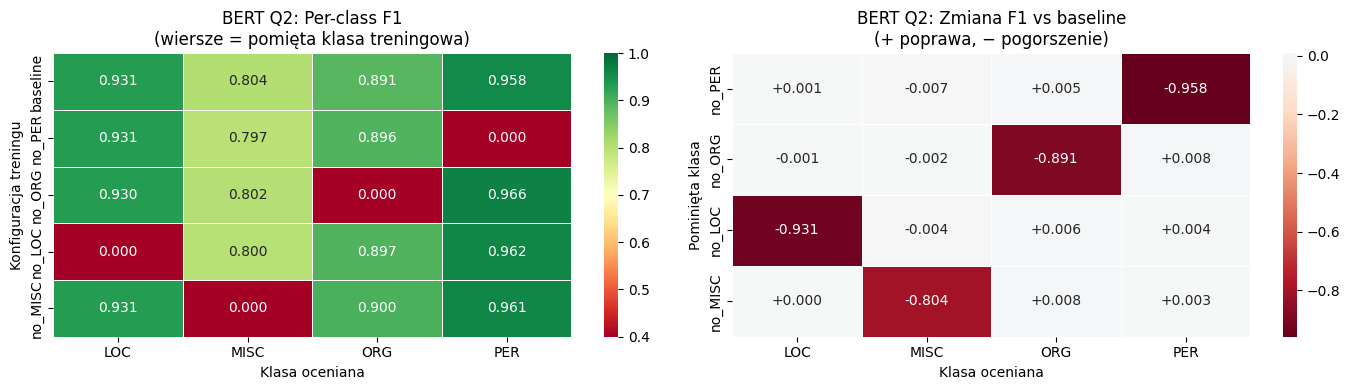

In [ ]:
def per_class_f1_q2(true_labels, true_preds):
    rep = classification_report(true_labels, true_preds, output_dict=True)
    return {cls: rep.get(cls, {}).get("f1-score", 0.0) for cls in Q2_CLASS_NAMES}

configs_q2_bert = list(q2_bert_results.keys())

df_q2_bert = pd.DataFrame(
    {cfg: per_class_f1_q2(*q2_bert_results[cfg]) for cfg in configs_q2_bert}
).T[Q2_CLASS_NAMES]

print("Per-class F1 (BERT Q2):")
print(df_q2_bert.to_string())

df_delta_bert = (
    df_q2_bert.drop("baseline") - df_q2_bert.loc["baseline"].values
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.heatmap(
    df_q2_bert.astype(float), annot=True, fmt=".3f",
    cmap="RdYlGn", linewidths=0.5, vmin=0.4, vmax=1.0,
    ax=axes[0]
)
axes[0].set_title("BERT Q2: Per-class F1\n(wiersze = pomięta klasa treningowa)")
axes[0].set_xlabel("Klasa oceniana")
axes[0].set_ylabel("Konfiguracja treningu")

sns.heatmap(
    df_delta_bert.astype(float), annot=True, fmt="+.3f",
    cmap="RdBu", center=0, linewidths=0.5,
    ax=axes[1]
)
axes[1].set_title("BERT Q2: Zmiana F1 vs baseline\n(+ poprawa, − pogorszenie)")
axes[1].set_xlabel("Klasa oceniana")
axes[1].set_ylabel("Pominięta klasa")

plt.tight_layout()
plt.savefig("q2_bert_results.png", dpi=150)
plt.show()


# Pytanie badawcze 3 (Fine-tuning): Ograniczenie treningu do pojedynczej klasy encji

In [ ]:
Q3_BERT_KEEP_CLASSES = ["PER", "ORG", "LOC", "MISC"]
Q3_BERT_MODEL_DIR    = "./q3_bert_models"
Q3_BERT_TRAIN        = True
Q3_CLASS_NAMES       = ["LOC", "MISC", "ORG", "PER"]

os.makedirs(Q3_BERT_MODEL_DIR, exist_ok=True)


def keep_only_class(raw_data: list, keep_class: str) -> list:
    keep = {f"B-{keep_class}", f"I-{keep_class}"}
    return [
        {"tokens": ex["tokens"],
         "ner_tags": [t if t in keep else "O" for t in ex["ner_tags"]]}
        for ex in raw_data
    ]


In [ ]:
q3_bert_results = {}

if "q2_bert_results" in dir() and "baseline" in q2_bert_results:
    q3_bert_results["baseline"] = q2_bert_results["baseline"]
    print("Baseline: załadowano z Q2.")
else:
    _base_dir = os.path.join(MODEL_SAVE_PATH, "final_model")
    _base_model = AutoModelForTokenClassification.from_pretrained(_base_dir)
    _base_args  = TrainingArguments(
        output_dir=MODEL_SAVE_PATH,
        per_device_eval_batch_size=BATCH_SIZE,
        report_to="none",
    )
    _base_trainer = Trainer(
        model=_base_model,
        args=_base_args,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
    q3_bert_results["baseline"] = predict_q2_bert(_base_trainer, test_dataset)
    print("Baseline: oceniono oryginalny model.")

for keep_class in Q3_BERT_KEEP_CLASSES:
    cfg       = f"only_{keep_class}"
    save_dir  = os.path.join(Q3_BERT_MODEL_DIR, cfg)
    final_dir = os.path.join(save_dir, "final_model")

    print(f"\n{'='*55}\nConfig: {cfg}")

    if Q3_BERT_TRAIN and not os.path.exists(final_dir):
        tok_train = tokenize_dataset(Dataset.from_list(keep_only_class(train_data, keep_class)))
        tok_val   = tokenize_dataset(Dataset.from_list(keep_only_class(val_data,   keep_class)))

        t = build_trainer_q2(tok_train, tok_val, save_dir)
        t.train()
        t.save_model(final_dir)
        tokenizer.save_pretrained(final_dir)
    else:
        m = AutoModelForTokenClassification.from_pretrained(final_dir)
        _args = TrainingArguments(
            output_dir=save_dir,
            per_device_eval_batch_size=BATCH_SIZE,
            report_to="none",
        )
        t = Trainer(
            model=m,
            args=_args,
            processing_class=tokenizer,
            data_collator=data_collator,
            compute_metrics=compute_metrics,
        )

    true_preds, true_labels = predict_q2_bert(t, test_dataset)
    q3_bert_results[cfg] = (true_preds, true_labels)
    print(classification_report(true_labels, true_preds))

print("\nQ3 BERT — wszystkie konfiguracje gotowe.")


Baseline: załadowano z Q2.

Config: only_PER


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 13534.00it/s]
[transformers] BertForTokenClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not

Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,0.065140,0.010090,0.971079,0.947883,0.959341
2,0.005493,0.007518,0.972492,0.978827,0.975649
3,0.002842,0.006904,0.972447,0.977199,0.974817
4,0.001391,0.007617,0.974040,0.977742,0.975887


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.49it/s]
[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'ber

/home/joachim/Desktop/University-NER/.venv/lib/python3.12/site-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


...

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 13815.28it/s]
[transformers] BertForTokenClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not

Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,0.074485,0.017640,0.857296,0.866594,0.861920
2,0.008026,0.017603,0.890217,0.888286,0.889251
3,0.002980,0.016951,0.888052,0.894794,0.891410
4,0.001187,0.020304,0.898803,0.895879,0.897338


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.70it/s]
[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'ber

              precision    recall  f1-score   support

         LOC       0.00      0.00      0.00      1668
        MISC       0.80      0.80      0.80       702
         ORG       0.00      0.00      0.00      1661
         PER       0.00      0.00      0.00      1617

   micro avg       0.80      0.10      0.18      5648
   macro avg       0.20      0.20      0.20      5648
weighted avg       0.10      0.10      0.10      5648


Q3 BERT — wszystkie konfiguracje gotowe.


/home/joachim/Desktop/University-NER/.venv/lib/python3.12/site-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


/home/joachim/Desktop/University-NER/.venv/lib/python3.12/site-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Per-class F1 (BERT Q3):
                LOC      MISC       ORG       PER
baseline   0.930746  0.803922  0.891176  0.957527
only_PER   0.000000  0.000000  0.000000  0.963653
only_ORG   0.000000  0.000000  0.897788  0.000000
only_LOC   0.923077  0.000000  0.000000  0.000000
only_MISC  0.000000  0.802276  0.000000  0.000000


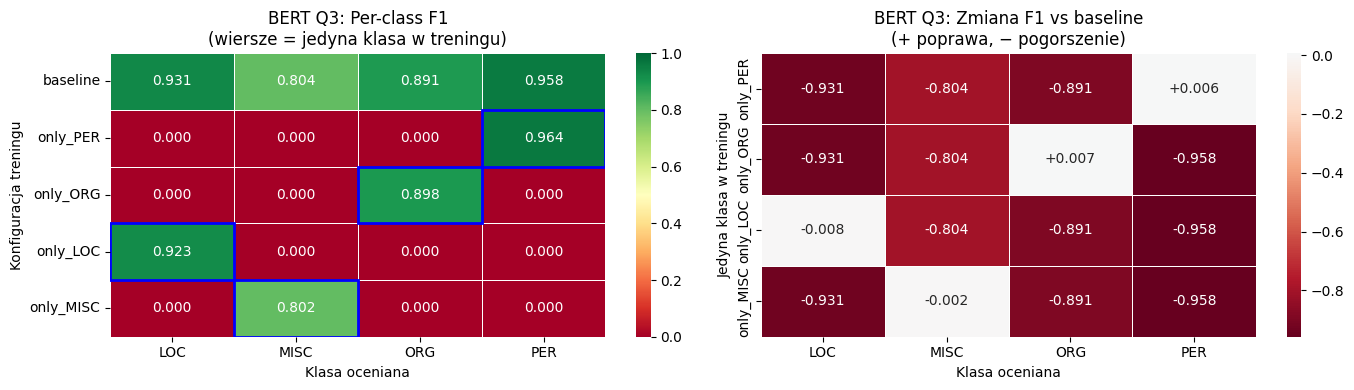

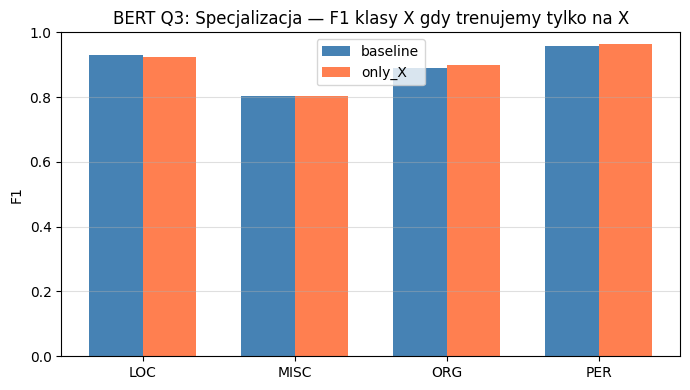

In [ ]:
configs_q3_bert = ["baseline"] + [f"only_{c}" for c in Q3_BERT_KEEP_CLASSES]

df_q3_bert = pd.DataFrame(
    {cfg: per_class_f1_q2(*q3_bert_results[cfg]) for cfg in configs_q3_bert}
).T[Q3_CLASS_NAMES]

print("Per-class F1 (BERT Q3):")
print(df_q3_bert.to_string())

df_delta_q3 = df_q3_bert.drop("baseline") - df_q3_bert.loc["baseline"].values

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.heatmap(
    df_q3_bert.astype(float), annot=True, fmt=".3f",
    cmap="RdYlGn", linewidths=0.5, vmin=0.0, vmax=1.0,
    ax=axes[0]
)
axes[0].set_title("BERT Q3: Per-class F1\n(wiersze = jedyna klasa w treningu)")
axes[0].set_xlabel("Klasa oceniana")
axes[0].set_ylabel("Konfiguracja treningu")

for i, cls in enumerate(Q3_CLASS_NAMES):
    cfg = f"only_{cls}"
    if cfg in configs_q3_bert:
        row_idx = configs_q3_bert.index(cfg)
        col_idx = Q3_CLASS_NAMES.index(cls)
        axes[0].add_patch(
            plt.Rectangle((col_idx, row_idx), 1, 1,
                           fill=False, edgecolor="blue", lw=2)
        )

sns.heatmap(
    df_delta_q3.astype(float), annot=True, fmt="+.3f",
    cmap="RdBu", center=0, linewidths=0.5,
    ax=axes[1]
)
axes[1].set_title("BERT Q3: Zmiana F1 vs baseline\n(+ poprawa, - pogorszenie)")
axes[1].set_xlabel("Klasa oceniana")
axes[1].set_ylabel("Jedyna klasa w treningu")

plt.tight_layout()
plt.savefig("q3_bert_results.png", dpi=150)
plt.show()

fig2, ax2 = plt.subplots(figsize=(7, 4))
baseline_f1 = [df_q3_bert.loc["baseline", cls] for cls in Q3_CLASS_NAMES]
only_f1     = [df_q3_bert.loc[f"only_{cls}", cls] for cls in Q3_CLASS_NAMES]

x = range(len(Q3_CLASS_NAMES))
w = 0.35
ax2.bar([i - w/2 for i in x], baseline_f1, w, label="baseline", color="steelblue")
ax2.bar([i + w/2 for i in x], only_f1,     w, label="only_X",   color="coral")
ax2.set_xticks(list(x))
ax2.set_xticklabels(Q3_CLASS_NAMES)
ax2.set_ylabel("F1")
ax2.set_ylim(0, 1)
ax2.set_title("BERT Q3: Specjalizacja — F1 klasy X gdy trenujemy tylko na X")
ax2.legend()
ax2.grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.savefig("q3_bert_specialization.png", dpi=150)
plt.show()


# Pytanie badawcze 4: Porównanie wszystkich konfiguracji — najlepsza jakość na 4 klasach

In [ ]:
import json
_bert_baseline_file = "bert_baseline_predictions.json"

if "q2_bert_results" in dir() and "baseline" in q2_bert_results:
    _true_preds, _true_labels = q2_bert_results["baseline"]
elif "q3_bert_results" in dir() and "baseline" in q3_bert_results:
    _true_preds, _true_labels = q3_bert_results["baseline"]
else:
    _m = AutoModelForTokenClassification.from_pretrained(MODEL_SAVE_PATH + "/final_model")
    _a = TrainingArguments(output_dir=MODEL_SAVE_PATH, per_device_eval_batch_size=BATCH_SIZE, report_to="none")
    _t = Trainer(model=_m, args=_a, processing_class=tokenizer,
                 data_collator=data_collator, compute_metrics=compute_metrics)
    _true_preds, _true_labels = predict_q2_bert(_t, test_dataset)

with open(_bert_baseline_file, "w", encoding="utf-8") as f:
    json.dump({"true_tags": _true_labels, "pred_tags": _true_preds}, f)

print(f"Saved BERT baseline predictions → {_bert_baseline_file}  ({len(_true_labels)} sentences)")


Saved BERT baseline predictions → bert_baseline_predictions.json  (3453 sentences)


In [ ]:
_all_bert_cfgs = {}

if "q2_bert_results" in dir():
    for cfg, (tp, tl) in q2_bert_results.items():
        _all_bert_cfgs[f"BERT_Q2_{cfg}"] = (tp, tl)

if "q3_bert_results" in dir():
    for cfg, (tp, tl) in q3_bert_results.items():
        if cfg != "baseline":
            _all_bert_cfgs[f"BERT_Q3_{cfg}"] = (tp, tl)

_bert_rows = []
for cfg, (tp, tl) in _all_bert_cfgs.items():
    rep = classification_report(tl, tp, output_dict=True)
    _bert_rows.append({
        "config":     cfg,
        "micro_f1":   round(rep.get("micro avg", {}).get("f1-score", 0.0), 4),
        "macro_f1":   round(rep.get("macro avg", {}).get("f1-score", 0.0), 4),
        "LOC_f1":     round(rep.get("LOC",  {}).get("f1-score", 0.0), 4),
        "MISC_f1":    round(rep.get("MISC", {}).get("f1-score", 0.0), 4),
        "ORG_f1":     round(rep.get("ORG",  {}).get("f1-score", 0.0), 4),
        "PER_f1":     round(rep.get("PER",  {}).get("f1-score", 0.0), 4),
        "n_sentences": len(tl),
    })

df_bert_q4 = pd.DataFrame(_bert_rows).sort_values("micro_f1", ascending=False)
print("BERT konfiguracje (sortowane wg micro F1):")
print(df_bert_q4.to_string(index=False))


/home/joachim/Desktop/University-NER/.venv/lib/python3.12/site-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


BERT konfiguracje (sortowane wg micro F1):
           config  micro_f1  macro_f1  LOC_f1  MISC_f1  ORG_f1  PER_f1  n_sentences
 BERT_Q2_baseline    0.9105    0.8958  0.9307   0.8039  0.8912  0.9575         3453
  BERT_Q2_no_MISC    0.8688    0.6979  0.9311   0.0000  0.8997  0.9609         3453
   BERT_Q2_no_ORG    0.7629    0.6743  0.9297   0.8017  0.0000  0.9656         3453
   BERT_Q2_no_LOC    0.7498    0.6647  0.0000   0.8000  0.8968  0.9618         3453
   BERT_Q2_no_PER    0.7455    0.6562  0.9315   0.7970  0.8962  0.0000         3453
 BERT_Q3_only_PER    0.4279    0.2409  0.0000   0.0000  0.0000  0.9637         3453
 BERT_Q3_only_LOC    0.4213    0.2308  0.9231   0.0000  0.0000  0.0000         3453
 BERT_Q3_only_ORG    0.4097    0.2244  0.0000   0.0000  0.8978  0.0000         3453
BERT_Q3_only_MISC    0.1776    0.2006  0.0000   0.8023  0.0000  0.0000         3453
